In [1]:
# ===== LIBRERÍAS =====
import time
import os
import tensorflow as tf
from tensorflow import keras
from keras import layers
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import StratifiedKFold, train_test_split
from ucimlrepo import fetch_ucirepo
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# ===== CAPA CHEBYSHEV SPECIALIST =====
class ChebyshevSpecialistLayer(tf.keras.layers.Layer):
    def __init__(self, degree=3, use_bias=True, **kwargs):
        super().__init__(**kwargs)
        self.degree = degree
        self.units = degree + 1
        self.use_bias = use_bias

    def build(self, input_shape):
        input_dim = input_shape[-1]

        self.kernel = self.add_weight(
            shape=(input_dim, self.units),
            initializer="glorot_uniform",
            trainable=True,
            name="cheb_specialist_kernel"
        )

        if self.use_bias:
            self.bias = self.add_weight(
                shape=(self.units,),
                initializer="zeros",
                trainable=True
            )

    def call(self, inputs):
        x = tf.cast(inputs, self.compute_dtype)

        # T0 = 1, T1 = x
        t0 = tf.ones_like(x)
        t1 = x

        polys = [t0, t1]

        prev_prev = t0
        prev = t1

        # Recurrencia Chebyshev: Tn = 2xTn-1 - Tn-2
        for _ in range(2, self.degree + 1):
            current = 2.0 * x * prev - prev_prev
            polys.append(current)
            prev_prev, prev = prev, current

        stacked = tf.stack(polys, axis=1)

        output = tf.einsum('buf,fu->bu', stacked, self.kernel)

        if self.use_bias:
            output = tf.nn.bias_add(output, self.bias)

        return output

In [3]:
# ===== PLOT =====
def plot_cv_average_history_cheb(histories_cheb):
    max_epochs_cheb = max([len(h.history['loss']) for h in histories_cheb])
    epochs_cheb = np.arange(1, max_epochs_cheb + 1)

    def get_padded_metrics_cheb(metric_name):
        matrix_cheb = np.full((len(histories_cheb), max_epochs_cheb), np.nan)
        for i, h in enumerate(histories_cheb):
            data_cheb = h.history[metric_name]
            matrix_cheb[i, :len(data_cheb)] = data_cheb
        return np.nanmean(matrix_cheb, axis=0)

    avg_loss_cheb = get_padded_metrics_cheb('loss')
    avg_val_loss_cheb = get_padded_metrics_cheb('val_loss')
    avg_acc_cheb = get_padded_metrics_cheb('accuracy')
    avg_val_acc_cheb = get_padded_metrics_cheb('val_accuracy')

    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_cheb, avg_loss_cheb)
    plt.plot(epochs_cheb, avg_val_loss_cheb)
    plt.title('Pérdida Promedio')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_cheb, avg_acc_cheb)
    plt.plot(epochs_cheb, avg_val_acc_cheb)
    plt.title('Precisión Promedio')

    plt.tight_layout()
    plt.show()


In [4]:
# ===== DATOS =====
idDataset = 53  # Cambia aquí
dataset = fetch_ucirepo(id=idDataset)

X = dataset.data.features.to_numpy()
y = dataset.data.targets.to_numpy()

# ===== HIPERPARÁMETROS =====
degrees = [3, 5, 10]
epochs = 300
batch_size = 32
num_splits = 10


In [5]:
def create_cheb(degree, input_dim, num_classes):
    inputs = keras.Input(shape=(input_dim,))

    x = ChebyshevSpecialistLayer(degree=degree)(inputs)
    x = layers.Activation('swish')(x)
    x = layers.Dense(16, activation='relu')(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs)

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [6]:
def createEarlyStoppingCallback(patience=15):
    return keras.callbacks.EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True)

In [7]:
# ===== CROSS VALIDATION =====
skf = StratifiedKFold(n_splits=num_splits, shuffle=True, random_state=1)

history = {deg: [] for deg in degrees}
scores = {deg: [] for deg in degrees}
times = {deg: [] for deg in degrees}

for train_idx, test_idx in skf.split(X, y):

    # Split
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Encoding
    le = LabelEncoder()
    y_train = le.fit_transform(y_train.ravel())
    y_test = le.transform(y_test.ravel())

    # Validación interna
    X_sub, X_val, y_sub, y_val = train_test_split(
        X_train, y_train,
        test_size=0.3,
        stratify=y_train,
        random_state=42
    )

    # Normalización
    scaler = MinMaxScaler(feature_range=(-1, 1))
    X_sub = scaler.fit_transform(X_sub)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)

    num_classes = len(np.unique(y_train))
    input_dim = X_sub.shape[1]

    for deg in degrees:
        tf.keras.backend.clear_session()

        model = create_cheb(degree=deg, input_dim=input_dim, num_classes=num_classes)

        start = time.time()

        hist = model.fit(
            X_sub, y_sub,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=batch_size,
            verbose=0,
        )

        end = time.time()

        result = model.evaluate(X_test, y_test, verbose=0)

        history[deg].append(hist)
        scores[deg].append(result)
        times[deg].append(end - start)

In [8]:
def calculator(scores, times):
    loss = np.mean([s[0] for s in scores])
    acc = np.mean([s[1] for s in scores])
    t = np.mean(times)
    return loss, acc, t

In [9]:
results = {}
for deg in degrees:
    results[deg] = calculator(scores[deg], times[deg])

os.makedirs("resultados", exist_ok=True)

data = []
for deg in degrees:
    loss, acc, t = results[deg]

    data.append({
        "Polinomio": "Chebyshev_Specialist",
        "Grado": deg,
        "Mejor_N": "N/A",
        "Loss_Promedio": round(loss, 6),
        "Accuracy_Promedio": round(acc, 6),
        "Tiempo_Promedio(s)": round(t, 2)
    })

pd.DataFrame(data).to_csv("resultados/resultados_chebyshev_specialist.csv", index=False, sep=';')


  RESULTADOS FINALES (Promedio CV - Chebyshev)
Grado 3: Pérdida Promedio = 0.1353, Precisión Promedio = 0.9600, Tiempo Promedio = 22.5531


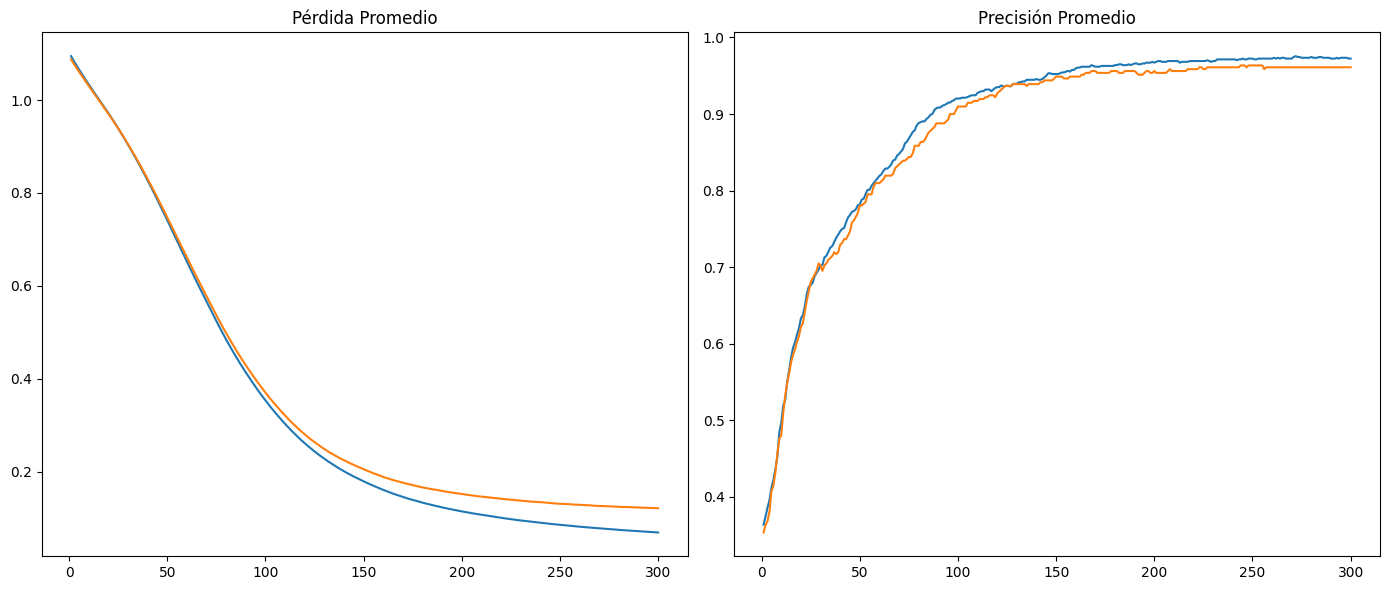

Grado 5: Pérdida Promedio = 0.1178, Precisión Promedio = 0.9533, Tiempo Promedio = 22.3030


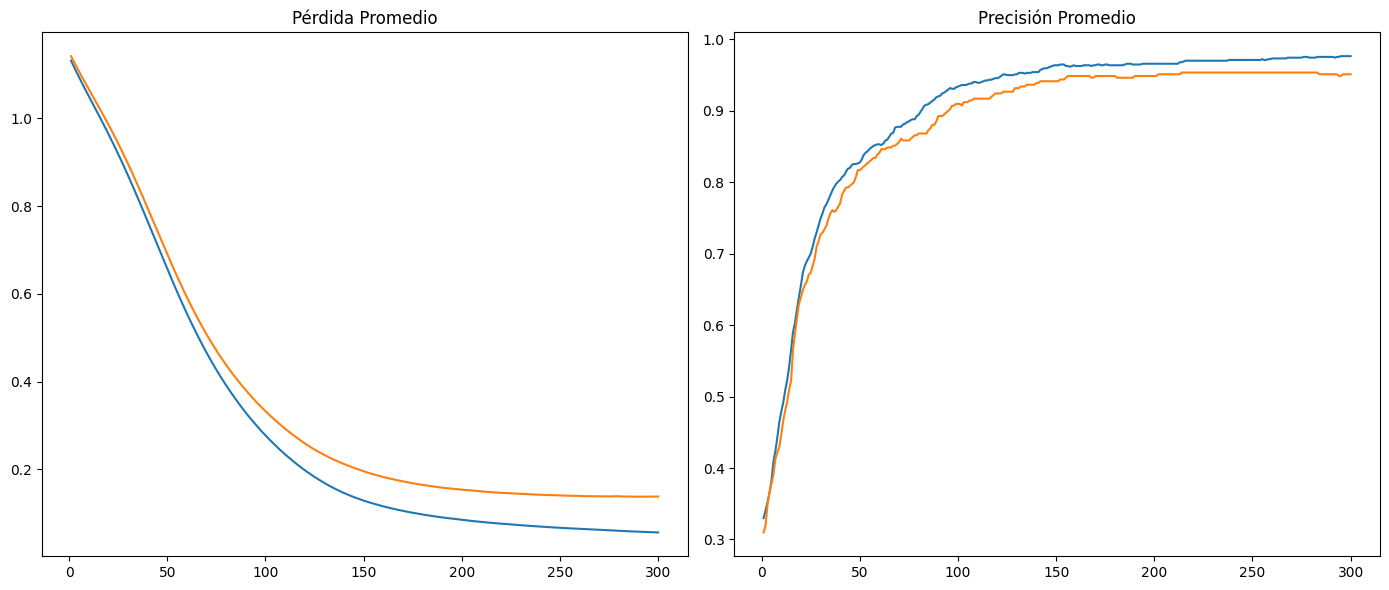

Grado 10: Pérdida Promedio = 0.9209, Precisión Promedio = 0.9400, Tiempo Promedio = 22.0245


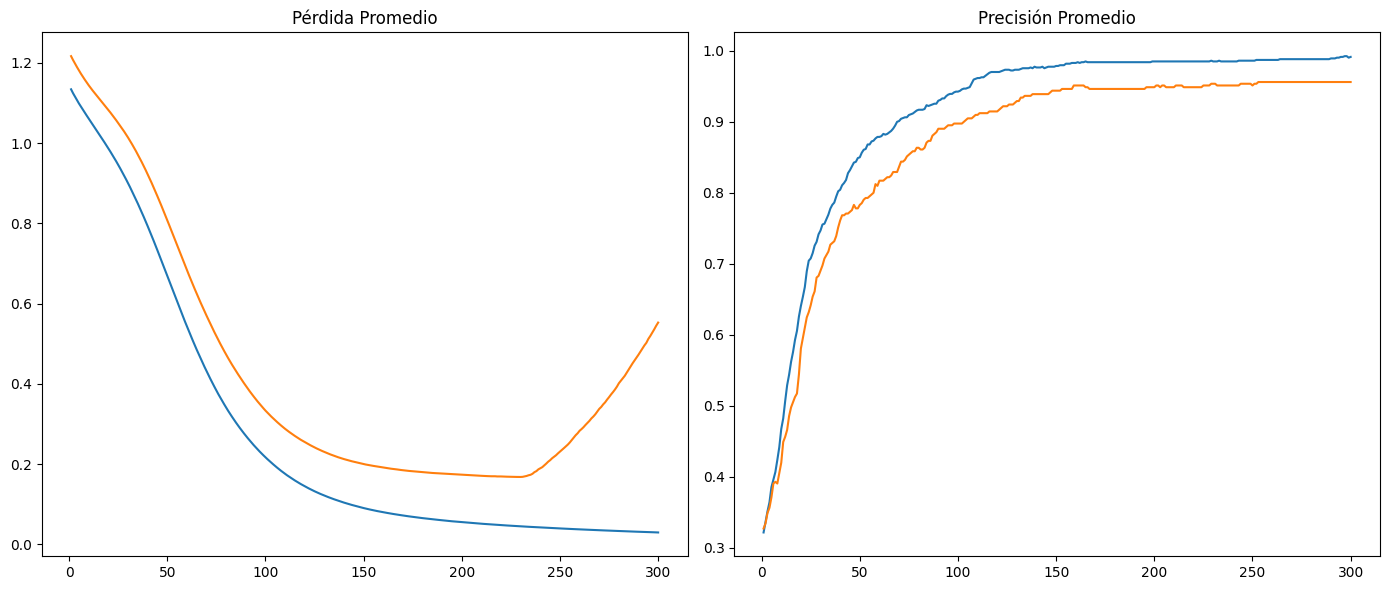

In [10]:
print("\n" + "="*40)
print("  RESULTADOS FINALES (Promedio CV - Chebyshev)")
print("="*40)

scoreMean_cheb = {}
for deg in degrees:
    scoreMean_cheb[deg] = calculator(scores[deg], times[deg])
    print(f"Grado {deg}: Pérdida Promedio = {scoreMean_cheb[deg][0]:.4f}, Precisión Promedio = {scoreMean_cheb[deg][1]:.4f}, Tiempo Promedio = {scoreMean_cheb[deg][2]:.4f}")
    plot_cv_average_history_cheb(history[deg])